In [2]:

import matplotlib.pyplot as plt
import Sudoku_matrix_9x9 as s_9x9
import time

In [3]:
from func_timeout import func_set_timeout
from func_timeout import FunctionTimedOut


@func_set_timeout(3)
def test(init, init_func):
    dic = init_func(init)
    matrix = s_9x9.generate_matrix(dic)
    t1 = time.perf_counter()
    sus = matrix.dancing([], 1)
    t2 = time.perf_counter()
    t = t2 - t1
    return t, sus


inits1 = []
times1 = []

inits2 = []
times2 = []

inits = []

fail_counts1 = []
fail_rates1 = []
timeout_counts1 = []
timeout_rates1 = []
avg_times1 = []

fail_counts2 = []
fail_rates2 = []
timeout_counts2 = []
timeout_rates2 = []
avg_times2 = []

for init in range(0, 21):
    n = 1000
    
    total_time1 = 0
    fail_count1 = 0
    timeout_count1 = 0

    total_time2 = 0
    fail_count2 = 0
    timeout_count2 = 0
    for i in range(n):
        try:
            res1 = test(init, s_9x9.sudoku_init_non_repeat)
            inits1.append(init)
            times1.append(res1[0])
            total_time1 += res1[0]
            if not res1[1]: fail_count1 += 1
            print(init, i, 'non repeat')
        except FunctionTimedOut:
            timeout_count1 += 1
            print(init, i, 'non repeat: time out')
        try:
            res2 = test(init, s_9x9.sudoku_init_rand)
            inits2.append(init)
            times2.append(res2[0])
            total_time2 += res2[0]
            if not res2[1]: fail_count2 += 1
            print(init, i, 'random')
        except FunctionTimedOut:
            timeout_count2 += 1
            print(init, i, 'random: time out')

    inits.append(init)
    
    fail_counts1.append(fail_count1)
    fail_rates1.append(fail_count1 / (n - timeout_count1))
    timeout_counts1.append(timeout_count1)
    timeout_rates1.append(timeout_count1 / n)
    avg_times1.append(total_time1 / (n - timeout_count1))

    fail_counts2.append(fail_count2)
    fail_rates2.append(fail_count2 / (n - timeout_count2))
    timeout_counts2.append(timeout_count2)
    timeout_rates2.append(timeout_count2 / n)
    avg_times2.append(total_time2 / (n - timeout_count2))
    


0 0 non repeat
0 0 random
0 1 non repeat
0 1 random
0 2 non repeat
0 2 random
0 3 non repeat
0 3 random
0 4 non repeat
0 4 random
0 5 non repeat
0 5 random
0 6 non repeat
0 6 random
0 7 non repeat
0 7 random
0 8 non repeat
0 8 random
0 9 non repeat
0 9 random
0 10 non repeat
0 10 random
0 11 non repeat
0 11 random
0 12 non repeat
0 12 random
0 13 non repeat
0 13 random
0 14 non repeat
0 14 random
0 15 non repeat
0 15 random
0 16 non repeat
0 16 random
0 17 non repeat
0 17 random
0 18 non repeat
0 18 random
0 19 non repeat
0 19 random
0 20 non repeat
0 20 random
0 21 non repeat
0 21 random
0 22 non repeat
0 22 random
0 23 non repeat
0 23 random
0 24 non repeat
0 24 random
0 25 non repeat
0 25 random
0 26 non repeat
0 26 random
0 27 non repeat
0 27 random
0 28 non repeat
0 28 random
0 29 non repeat
0 29 random
0 30 non repeat
0 30 random
0 31 non repeat
0 31 random
0 32 non repeat
0 32 random
0 33 non repeat
0 33 random
0 34 non repeat
0 34 random
0 35 non repeat
0 35 random
0 36 non rep

Text(0, 0.5, 'Timeout Rate')

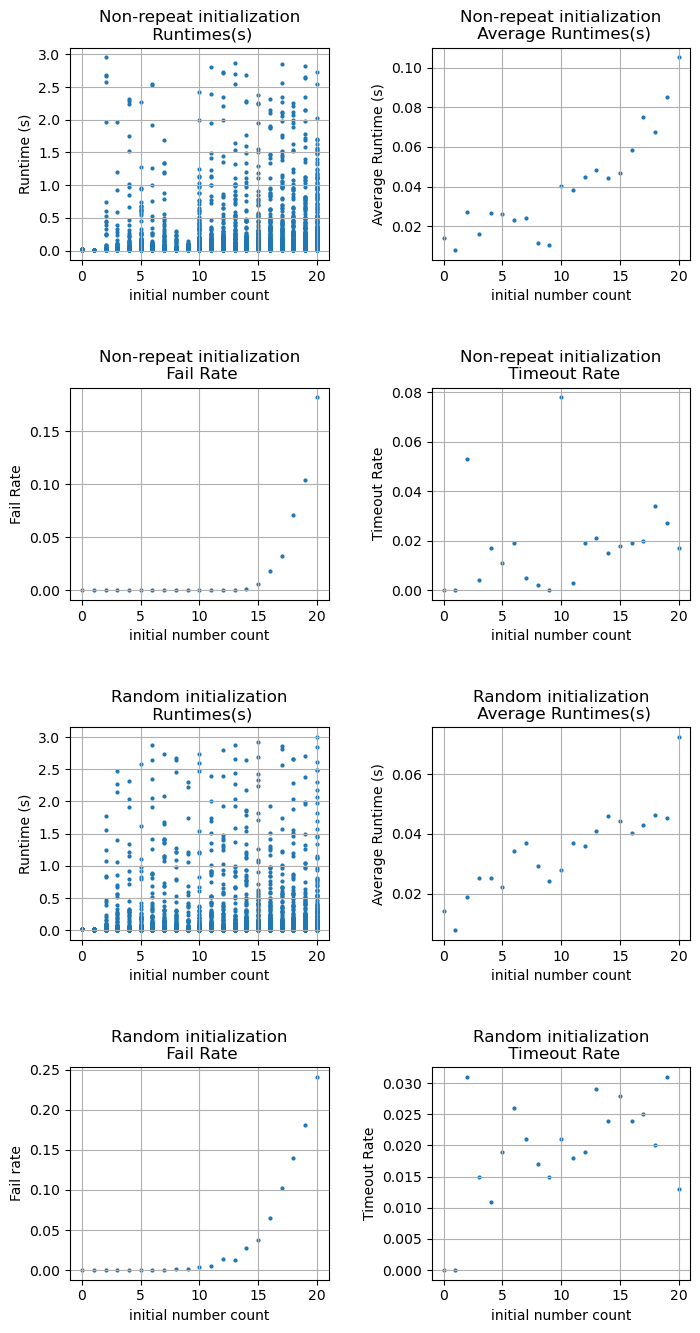

In [4]:

res = (
    ((inits1, times1), (inits, avg_times1)),
    ((inits, fail_rates1), (inits, timeout_rates1)),
    ((inits2, times2), (inits, avg_times2)),
    ((inits, fail_rates2), (inits, timeout_rates2))
)

fig = plt.figure(figsize=(8, 16))
fig.subplots_adjust( wspace=0.4,hspace=0.6)
axs:list[list[plt.Axes]] = []
for i in range(len(res)):
    axs.append([])
    for j in range(len(res[i])):
        axs[i].append(fig.add_subplot(len(res), 2, len(res[i]) * i + j + 1))
        axs[i][j].scatter(res[i][j][0], res[i][j][1], 4)
        axs[i][j].set_xlabel('initial number count')
        axs[i][j].grid(True)

axs[0][0].set_title('Non-repeat initialization\n Runtimes(s)')
axs[0][0].set_ylabel('Runtime (s)')

axs[0][1].set_title('Non-repeat initialization\n Average Runtimes(s)')
axs[0][1].set_ylabel('Average Runtime (s)')

axs[1][0].set_title('Non-repeat initialization\n Fail Rate')
axs[1][0].set_ylabel('Fail Rate')

axs[1][1].set_title('Non-repeat initialization\n Timeout Rate')
axs[1][1].set_ylabel('Timeout Rate')

axs[2][0].set_title('Random initialization\n Runtimes(s)')
axs[2][0].set_ylabel('Runtime (s)')

axs[2][1].set_title('Random initialization\n Average Runtimes(s)')
axs[2][1].set_ylabel('Average Runtime (s)')

axs[3][0].set_title('Random initialization\n Fail Rate')
axs[3][0].set_ylabel('Fail rate')

axs[3][1].set_title('Random initialization\n Timeout Rate')
axs[3][1].set_ylabel('Timeout Rate')


In [1]:
import numpy as np
import Sudoku_matrix_9x9 as s_9x9
test = np.array([[0, 0, 4, 5, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 9, 0, 0, 0],
[5, 0, 9, 3, 0, 0, 0, 0, 2],
[2, 0, 0, 0, 0, 0, 0, 0, 7],
[4, 0, 0, 0, 0, 0, 0, 0, 0],
[6, 0, 0, 0, 0, 0, 2, 0, 0],
[0, 0, 0, 0, 0, 0, 9, 0, 0],
[0, 0, 0, 7, 0, 0, 6, 1, 0],
[9, 0, 7, 0, 5, 0, 0, 0, 0]])
s_9x9.check_unique_answer(s_9x9.to_dic(test))

False